<center>
    <img src="https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/Logos/organization_logo/organization_logo.png" width="300" alt="cognitiveclass.ai logo">
</center>


#### Import the required libraries we need for the lab.


In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pyplot
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import levene, ttest_ind, f_oneway, pearsonr

boston_df = pd.read_csv("/home/moacir/projects/ml/IBM/statistics/data/raw/boston_housing.csv")

#### Read the dataset in the csv file from the URL


In [2]:
boston_df=pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv')

In [ ]:
boston_df.to_csv("/home/moacir/projects/ml/IBM/statistics/data/raw/boston_housing.csv", index=False)

<a id="inicio"></a>
**Data Description**  

|Columns|Describe|PT|
|-|-|-|
|Unnamed:     |   int64 | Sem nome |
|CRIM         | Key metrics include crime rate | As principais métricas incluem a taxa de criminalidade |
|ZN           | residential zoning | Zoneamento residencial |
|INDUS        | non-retail business acres / industrial proportion | Área destinada a negócios não comerciais / proporção industrial |
|CHAS         | Charles River dummy variable / river proximity | Variável dummy do Rio Charles / proximidade do rio |
|NOX          | nitric oxide concentrations / air pollution | Concentrações de óxido nítrico / poluição do ar |
|RM           | average rooms | Média de quartos |
|AGE          | building age | Idade do edifício |
|DIS          | distance to employment centres / employment distance | Distância a centros de emprego / distância do emprego |
|RAD          | highway access | Acesso a rodovias |
|TAX          | tax rate | Alíquota de imposto |
|PTRATIO      | pupil-teacher ratio | Relação aluno-professor |
|LSTAT        | a calculated demographic factor (B), and lower-status population percentage | Um fator demográfico calculado (B) e a porcentagem da população de baixa renda |
|MEDV         | Median value of owner-occupied homes | Valor mediano de residências próprias |

#### Add your code below following the instructions given in the course to complete the peer graded assignment


[↑ Início](#inicio)
## Task 1: Familiarize Yourself with the Dataset

1. **Display the first 5 rows of the dataset**

In [45]:
boston_df.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


2. **Display the data types of each column**

In [28]:
boston_df.dtypes

Unnamed: 0      int64
CRIM          float64
ZN            float64
INDUS         float64
CHAS          float64
NOX           float64
RM            float64
AGE           float64
DIS           float64
RAD           float64
TAX           float64
PTRATIO       float64
LSTAT         float64
MEDV          float64
dtype: object

3. **Check for missing values in each column**

In [29]:
boston_df.isnull().sum()

Unnamed: 0    0
CRIM          0
ZN            0
INDUS         0
CHAS          0
NOX           0
RM            0
AGE           0
DIS           0
RAD           0
TAX           0
PTRATIO       0
LSTAT         0
MEDV          0
dtype: int64

4. **Check for duplicate rows**

In [30]:
boston_df.duplicated().sum()

np.int64(0)

5. **Display the correlation matrix of the dataset**

In [31]:
boston_df.corr()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
Unnamed: 0,1.000000,0.407407,-0.103393,0.399439,-0.003759,0.398736,-0.079971,0.203784,-0.302211,0.686002,0.666626,0.291074,0.258465,-0.226604
CRIM,0.407407,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,0.455621,-0.388305
ZN,-0.103393,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,-0.412995,0.360445
INDUS,0.399439,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,0.603800,-0.483725
CHAS,-0.003759,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,-0.053929,0.175260
NOX,0.398736,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,0.590879,-0.427321
RM,-0.079971,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,-0.613808,0.695360
AGE,0.203784,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,0.602339,-0.376955
DIS,-0.302211,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,-0.496996,0.249929
RAD,0.686002,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,0.488676,-0.381626


[↑ Início](#inicio)
## Task 2: Generate Descriptive Statistics and Visualizations

1. **Display descriptive statistics of the dataset**

In [32]:
boston_df.describe()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,252.500000,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,146.213884,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,126.250000,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,252.500000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,378.750000,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,505.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


2. **Create a boxplot for MEDV (Median value of owner-occupied homes)**

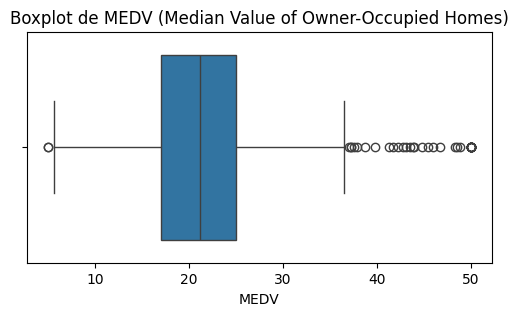

In [33]:
pyplot.figure(figsize=(6, 3)); pyplot.title("Boxplot de MEDV (Median Value of Owner-Occupied Homes)")
medv = sns.boxplot(x=boston_df["MEDV"])

- Interpretação
    - A mediana está em 21.200
    - Q1 = 17.025 e Q3 = 25.000 $\to\qquad$ 50% estão ente 17.025 e 25.000
    - A caixa esta puxada para os menores valores
    - os outliers estão concentrados acima de 35.000

- Interpretation
    - The median is at 21.200
    - Q1 = 17.025 and Q3 = 25.000 $\to\qquad$ 50% are between 17.025 and 25.000
    - The box is pulled towards the lower values
    - The outliers are concentrated above 35.000

3. **Create a bar plot for CHAS (Charles River dummy variable)**

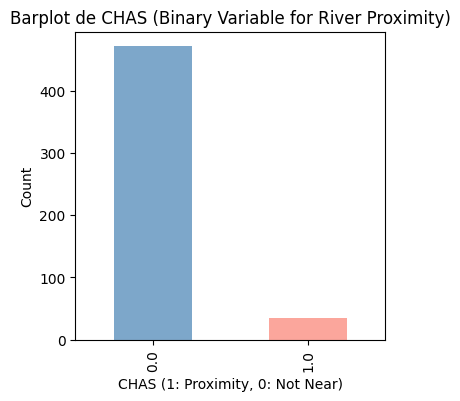

,CHAS,count
0,0.0,471
1,1.0,35


In [34]:
pyplot.figure(figsize=(4, 4)); pyplot.title("Barplot de CHAS (Binary Variable for River Proximity)")
j = boston_df["CHAS"].value_counts().plot(kind="bar", alpha=0.7, color=["steelblue", "salmon"])
pyplot.xlabel("CHAS (1: Proximity, 0: Not Near)"); pyplot.ylabel("Count")
pyplot.show()

boston_df["CHAS"].value_counts().reset_index()

- Interpretação
    - Do total de 506 unidade
        - 471 tem CHAS = 0 $\to\qquad$ não estão próximas ao rio.
        - 035 tem CHAS = 1 $\to\qquad$ estão próximo ao rio
    - A grande maioria das casas estão longe do rio.

- Interpretation
    - Of the total 506 units
        - 471 have CHAS = 0 $\to \qquad$ are not near the river.
        - 035 have CHAS = 1 $\to \qquad$ are near the river.
- The vast majority of houses are far from the river.

4. **Discretize AGE into three groups and create a boxplot of MEDV versus these groups**

In [35]:
boston_df["AGE"].describe().reset_index()

,index,AGE
0,count,506.000000
1,mean,68.574901
2,std,28.148861
3,min,2.900000
4,25%,45.025000
5,50%,77.500000
6,75%,94.075000
7,max,100.000000


In [46]:
boston_df.loc[(boston_df['AGE'] <= 30), 'AGE_GROUP'] = '30 years or younger'
boston_df.loc[(boston_df['AGE'] > 30)&(boston_df['AGE'] < 65), 'AGE_GROUP'] = '31 to 65 years'
boston_df.loc[(boston_df['AGE'] >= 65), 'AGE_GROUP'] = '65 years or older'

,AGE_GROUP,count,mean,std,min,25%,50%,75%,max
0,30 years or younger,64.0,27.382812,6.790202,17.1,23.100,24.80,31.125,50.0
1,31 to 65 years,134.0,25.855970,7.660489,10.2,20.725,23.15,29.000,50.0
2,65 years or older,308.0,20.079221,9.407057,5.0,14.100,18.65,22.725,50.0


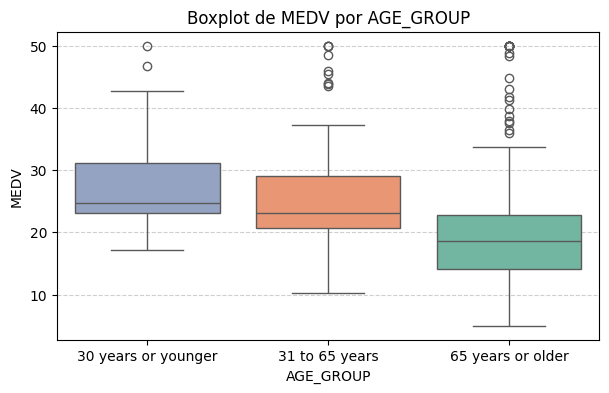

In [37]:
pyplot.figure(figsize=(7, 4)); pyplot.title("Boxplot de MEDV por AGE_GROUP"); pyplot.grid(axis="y", linestyle="--", alpha=0.6)
i = sns.boxplot(x="AGE_GROUP", y="MEDV", hue="AGE_GROUP", data=boston_df, palette="Set2",
                order=["30 years or younger", "31 to 65 years", "65 years or older"])

boston_df.groupby("AGE_GROUP")["MEDV"].describe().reset_index()

- Interpretação
    - 30 years or younger
        - count: 64
        - Média: 27.38
        - Mediana: 24.80
        - IQR: 23.10 <> 31.12
        - É o grupo com maiores valores de MEDV
    - 31 to 65 years
        - count: 134
        - Média: 25,85
        - Mediana: 23.15
        - IQR: 20.72 <> 29.00
    - 65 years or older
        - count: 308
        - Média: 20.07
        - Mediana: 18.65
        - IQR: 14.10 <> 22.72
    - Comparação entre grupos
        - Existe um número muito menor de unidades com construções mais novas (≤ 30 anos)
        - Os maiores valores de MEDV aparecem nos bairros com construções mais novas
        - A maior parte das unidades está em bairros com construções mais antigas (≥ 65 anos)
        - Os outliers no grupo mais antigo são mais numerosos, mas a maioria das casas antigas tem MEDV baixo
        - Quanto mais nova a contrução, maior tende a ser MEDV

- Interpretation
    - 30 years or younger
        - Count: 64
        - Mean: 27.38
        - Median: 24.80
        - IQR: 23.10 <> 31.12
        - This is the group with the highest MEDV values
    - 31 to 65 years
        - Count: 134
        - Mean: 25.85
        - Median: 23.15
        - IQR: 20.72 <> 29.00
    - 65 years or older
        - Count: 308
        - Mean: 20.07
        - Median: 18.65
        - IQR: 14.10 <> 22.72
- Comparison between groups
    - There is a much smaller number of units with newer constructions (≤ 30 years)
    - The highest MEDV values ​​appear in neighborhoods with newer constructions
    - Most units are in neighborhoods with newer constructions Older (≥ 65 years)
    - Outliers in the oldest group are more numerous, but most older houses have a low MEDV (Medium Density Value).
    - The newer the construction, the higher the MEDV tends to be.

5. **Create a scatter plot showing the relationship between NOX (nitric oxide concentrations) and INDUS (non-retail business acres)**

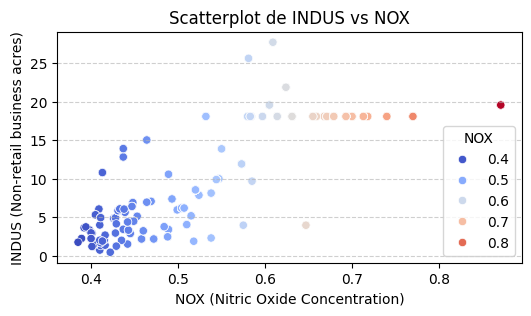

In [38]:
pyplot.figure(figsize=(6, 3)); pyplot.title("Scatterplot de INDUS vs NOX"); pyplot.grid(axis="y", linestyle="--", alpha=0.6)
pyplot.ylabel("INDUS (Non-retail business acres)"); pyplot.xlabel("NOX (Nitric Oxide Concentration)")
k = sns.scatterplot(x="NOX", y="INDUS", hue="NOX", data=boston_df, palette="coolwarm")

- Interpretação
    - Há uma tendência onde: À medida que INDUS aumenta, a concentração de NOX também aumenta
        - Areas com maior proporção de terrenos industriais apresentam maior quantidade de óxidos de nitrogênio
        - Quando INDUS esta entre 15 e 20, NOX tende a ser mais concentrado
        - A escala de cores reforça visualmente essa tendência
    - Existe uma relação positiva entre INDUS e NOX

- Interpretation
    - There is a trend where: As INDUS increases, the concentration of NOX also increases.
        - Areas with a higher proportion of industrial land have a greater amount of nitrogen oxides.
        - When INDUS is between 15 and 20, NOX tends to be more concentrated.
        - The color scale visually reinforces this trend.
    - There is a positive relationship between INDUS and NOX.

6. **Create a histogram for PTRATIO (pupil-teacher ratio)**

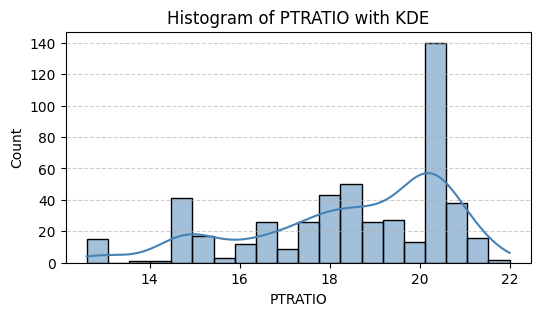

In [ ]:
pyplot.figure(figsize=(6, 3)); pyplot.title("Histogram of PTRATIO with KDE"); pyplot.grid(axis="y", linestyle="--", alpha=0.6)
i =sns.histplot(boston_df["PTRATIO"], bins=20, kde=True, color="steelblue")

- Interpretação
    - A distribuição de PTRATIO é concentrada entre 18 e 22
    - existe um pico próximo de 20,  indicando que essa é a razão aluno‑professor mais comum
    - A curva KDE mostra uma distribuição com leve assimetria

- Interpretation
    - The PTRATIO distribution is concentrated between 18 and 22
    - There is a peak near 20, indicating that this is the most common student-to-teacher ratio
    - The KDE curve shows a distribution with slight asymmetry

[↑ Início](#inicio)
## Task 3: Apply Statistical Tests

1. **Use Levene’s test to check if the variances of MEDV for homes bounded by the Charles River (CHAS = 1) and those not bounded (CHAS = 0) are equal**

In [40]:
levene( boston_df[boston_df["CHAS"] == 1]["MEDV"],
        boston_df[boston_df["CHAS"] == 0]["MEDV"],
        center='mean')

LeveneResult(statistic=np.float64(8.75190489604598), pvalue=np.float64(0.0032381193676394252))

- Interpretação
    - (pvalue = 0,003) < 0,05 
        - Variâncias diferentes
        - Para MEDV, entre os 2 grupos as variâncias são significativamente diferentes 

- Interpretation
    - (p-value = 0.003) < 0.05
        - Different variances
        - For MEDV, the variations between the two groups are significantly different

2. **Perform a T-test to determine if there is a significant difference in MEDV between homes bounded and not bounded by the Charles River**

In [41]:
ttest_ind(  boston_df[boston_df["CHAS"] == 1]["MEDV"],
            boston_df[boston_df["CHAS"] == 0]["MEDV"],
            equal_var=False)

TtestResult(statistic=np.float64(3.113291312794837), pvalue=np.float64(0.003567170098137519), df=np.float64(36.876408797611994))

- Interpretação
    - (pvalue = 0.003) < 0.05
    - Rejeitamos $H_0$ e concluímos que existe diferença significativa entre as médias de MEDV para CHAS = 1 e CHAS = 0
    - Casas próximas ao rio (CHAS = 1) apresentam MEDV significativamente maior
    - CHAS é uma variável relevante para explicar variações no valor das casas

- Interpretation
    - (p-value = 0.003) < 0.05
    - We reject $H_0$ and conclude that there is a significant difference between the mean MEDV for CHAS = 1 and CHAS = 0
    - Houses near the river (CHAS = 1) show a significantly higher MEDV
    - CHAS is a relevant variable to explain variations in house value

3. **Conduct an ANOVA test to compare MEDV among the three AGE groups created earlier**

In [57]:
g1 = boston_df[boston_df['AGE_GROUP'] == '30 years or younger']["MEDV"]
g2 = boston_df[boston_df['AGE_GROUP'] == '31 to 65 years']["MEDV"]
g3 = boston_df[boston_df['AGE_GROUP'] == '65 years or older']["MEDV"]

In [48]:
f_statistic, p_value = f_oneway(g1, g2, g3)
print("F_Statistic: {0}, P-Value: {1}".format(f_statistic, p_value))

F_Statistic: 32.13363823471252, P-Value: 7.357559437896264e-14


- Interpretação
    - f_Statistic = 32.13
    - (pvalue = 7.35e-14) < 0.05 
    - Rejeitamos $H_0$ $\to\qquad$ as médias diferem entre os grupos
    - Unidades mais novas tendem a ser mais valorizadas

- Interpretation
    - f_Statistic = 32.13
    - (p-value = 7.35e-14) < 0.05
    - We reject $H_0$ $\to\qquad$ as the means differ between the groups
    - Newer units tend to be more valued

4. **Perform a Pearson correlation test to assess the relationship between NOX and INDUS**

In [ ]:
pearsonr(boston_df["INDUS"], boston_df["NOX"])

PearsonRResult(statistic=np.float64(0.7636514469209154), pvalue=np.float64(7.913361061239639e-98))

- Interpretação
    - r = 0.76
    - (pvalue = 7,91e-98) < 0.05
    - Existe correlação positiva entre NOX e INDUS
    - Quando INDUS aumenta NOX tende a aumentar, e essa relação é forte (r = 0.76)

- Interpretation
    - r = 0.76
    - (p-value = 7.91e-98) < 0.05
    - There is a positive correlation between NOX and INDUS
    - When INDUS increases, NOX tends to increase, and this relationship is strong (r = 0.76)

5. **Fit a simple linear regression model to evaluate the impact of DIS (distance to employment centres) on MEDV. Report and interpret the regression results**

In [56]:
X = boston_df["DIS"]
y = boston_df["MEDV"]
X = sm.add_constant(X)
model_1 = sm.OLS(y, X).fit()
predictions = model_1.predict(X)
model_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Thu, 14 May 2026   Prob (F-statistic):           1.21e-08
Time:                        18:15:53   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.000      16.784      19.996
DIS            1.0916      0.188      5.795      0.000       0.722       1.462
==============================================================================
Omnibus:                      139.779   Durbin-Watson:                   0.570
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              305.104
Skew:                           1.466   Prob(JB):                     5.59e-67
Kurtosis:                       5.424   Cond. No.                         9.32
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

- Interpretação
    - intercepto: 18.39 $\to\qquad$ MEDV quando DIS = 0
    - coef DIS: 1.09 $\to\qquad$ para cada unidade em DIS, o valor médio de MEDV aumenta aproximadamente 1.09
    - (DIS pvalue = 0.000) < 0.005 $\to\qquad$ DIS é estatisticamente significativo para MEDV
    - F-statistics: 33.58
    - Prob (F-statistics): 1.21e-08
    - $R^2$: 0.062 $\to\qquad$ Pelo modelo existe 6.2% da variação de MEDV

- Interpretation
    - Intercept: 18.39 MEDV when DIS = 0
    - DIS coefficient: 1.09 For each unit in DIS, the mean value of MEDV increases approximately 1.09
    - (DIS pvalue = 0.000) < 0.005 DIS is statistically significant for MEDV
    - F-statistics: 33.58
    - Prob (F-statistics): 1.21e-08
    - R^2: 0.062 According to the model, there is 6.2% of the variation in MEDV